# 计算机视觉基础课程实验二报告

> 主题：图像检索与文字检测  
> 数据集：交大视觉印象数据集 2026  

## 目录

- [1. 实验目标](#1-实验目标)
- [2. 数据集说明](#2-数据集说明)
- [3. 实验环境](#3-实验环境)
- [4. 方法设计](#4-方法设计)
- [5. 图像检索结果](#5-图像检索结果)
- [6. 文字检测结果](#6-文字检测结果)
- [7. 可视化展示](#7-可视化展示)
- [8. 结果分析](#8-结果分析)
- [9. 结论](#10-结论)

## 1. 实验目标

实验二包含两个任务：

1. 图像检索：给定查询图 `query`，在图库 `base` 中完成以图搜图。
2. 文字检测：检测校园图片中的文字区域，并展示“检索 + 检测”综合结果。

## 2. 数据集说明

课程提供的数据集包含两部分：

### 2.1 图像检索

| 数据划分 | 内容 | 数量 |
| --- | --- | ---: |
| `base/BJTU` | 交大相关图库图像 | 2665 |
| `base/util_pic` | 无关干扰图像 | 5063 |
| `query` | 查询图像 | 135 |

### 2.2 文字检测

| 数据划分 | 内容 | 数量 |
| --- | --- | ---: |
| `object_detection/data` | 带 LabelMe 标注的文字检测图像 | 1494 |

说明：

- 图像检索按照文件名前缀判断是否为同类 landmark。
- 文字检测原始标注中存在矩形框和多边形标注，实验中统一转成外接矩形框。

## 3. 实验环境

| 项目 | 配置 |
| --- | --- |
| 操作系统 | Windows |
| Python | Anaconda Python 3.13.5 |
| 深度学习框架 | PyTorch、Torchvision |
| 主要依赖 | NumPy、Pillow、Matplotlib |
| 硬件 | 单张可用 GPU |

## 4. 方法设计

### 4.1 图像检索方法

图像检索部分采用预训练 `ResNet18` 作为特征提取网络，流程如下：

1. 对 `base/BJTU` 和 `query` 中的图像做统一预处理。
2. 使用 ImageNet 预训练 `ResNet18` 提取全局特征。
3. 对特征做 L2 归一化。
4. 使用余弦相似度进行相似图排序。
5. 对每个查询图输出 Top-60 结果，并统计 `P@20`、`P@40`、`P@60`。

选择该方案的原因是：

- 实现简单，适合作为课程实验基线。
- 无需重新训练检索模型。
- 推理速度较快，便于直接生成全量结果。

### 4.2 文字检测方法

文字检测部分采用预训练目标检测模型 `Faster R-CNN MobileNetV3 320 FPN`，流程如下：

1. 读取 LabelMe 标注。
2. 将多类别文字标签统一视为单一 `text` 类别。
3. 将矩形框和多边形标注统一转换为矩形框。
4. 从查询集为每个 landmark 保留 2 张图像，共 24 张，作为最终展示样例。
5. 剩余带标注图像划分为训练集与验证集，进行 4 个 epoch 微调。
6. 输出检测指标，并生成“查询图 + 检测结果 + Top-5 检索结果”的可视化面板。

数据划分如下：

| 划分 | 数量 |
| --- | ---: |
| 训练集 | 1324 |
| 验证集 | 146 |
| 最终展示样例 | 24 |

## 5. 图像检索结果

### 5.1 整体结果

本实验最终使用了：

- 可读取图库图像：2664 张
- 查询图像：135 张
- 被自动跳过的损坏图像：1 张

损坏图像文件名如下：

```text
ty-1746580766456.jpg
```

整体 Precision@K 结果如下：

| 指标 | 数值 |
| --- | ---: |
| P@20 | 0.859 |
| P@40 | 0.819 |
| P@60 | 0.782 |

### 5.2 各类 landmark 结果

| 类别 | P@20 | P@40 | P@60 |
| --- | ---: | ---: | ---: |
| fhy | 0.913 | 0.882 | 0.856 |
| jx  | 0.714 | 0.586 | 0.512 |
| kx  | 0.150 | 0.088 | 0.058 |
| mh  | 0.875 | 0.837 | 0.807 |
| nm  | 0.923 | 0.907 | 0.871 |
| sjz | 0.970 | 0.963 | 0.948 |
| sy  | 0.810 | 0.798 | 0.742 |
| tsg | 0.880 | 0.822 | 0.782 |
| ty  | 0.932 | 0.888 | 0.852 |
| yf  | 0.621 | 0.511 | 0.460 |
| yk  | 0.500 | 0.350 | 0.275 |
| zx  | 0.893 | 0.879 | 0.849 |

### 5.3 检索曲线图

下图为 12 个 landmark 的 Precision 曲线图：

![图像检索 Precision 曲线](outputs/retrieval/precision_curves.png)

从结果可以看出：

- `sjz`、`nm`、`ty`、`fhy` 的检索效果较好。
- `kx`、`yk`、`yf`、`jx` 的结果相对偏弱。
- 样本数量较少、外观变化较大的类别更容易受到背景干扰。

## 6. 文字检测结果

### 6.1 训练配置

| 项目 | 数值 |
| --- | ---: |
| Epoch | 4 |
| Batch Size | 4 |
| Learning Rate | 0.0025 |
| Score Threshold | 0.5 |
| IoU Threshold | 0.5 |

### 6.2 验证集结果

| 指标 | 数值 |
| --- | ---: |
| Precision | 0.870 |
| Recall | 0.572 |
| F1 | 0.690 |
| Mean IoU | 0.748 |

### 6.3 24 张展示样例结果

| 指标 | 数值 |
| --- | ---: |
| Holdout Precision | 0.727 |
| Holdout Recall | 0.333 |
| Holdout F1 | 0.457 |
| Holdout Mean IoU | 0.794 |

可以看出该检测器有一个比较明显的特点：

- 优点：一旦检测到文字，框的位置通常较准确。
- 不足：召回率偏低，存在一定漏检。

### 6.4 训练曲线

下图展示了训练损失与验证集 F1 的变化趋势：

![文字检测训练曲线](outputs/detection/training_curve.png)

## 7. 可视化展示

按照课程要求，本实验为每个 landmark 保留了 2 组“检索 + 检测”结果，共 24 组可视化样例。

每组样例包含：

1. 查询图
2. 查询图上的文字检测结果
3. Top-5 图像检索结果

24 组样例总览如下：

![24 组检索-检测结果总览](outputs/detection/visualizations_contact_sheet.jpg)

完整单张面板位于目录：

- `outputs/detection/visualizations/`

## 8. 结果分析

### 8.1 图像检索分析

检索结果说明预训练卷积特征对于多数校园 landmark 具有较好的区分能力，尤其是：

- 外观稳定的建筑或标志物
- 构图较集中、背景较简单的样本

性能较弱的类别通常具有以下特点：

- 样本总量较少
- 不同视角差异较大
- 容易与其他建筑或景观混淆

### 8.2 文字检测分析

检测模型整体表现为“高精度、偏低召回”：

- 对清晰、面积较大、对比明显的文字区域效果较好
- 对远距离、倾斜严重、背景复杂的样本容易漏检

### 8.3 后续改进方向

可以考虑以下优化方向：

1. 图像检索尝试更强主干网络，如 `ResNet50`、`ConvNeXt`、`ViT`。
2. 增加检索重排序或局部特征匹配，提高困难类别效果。
3. 文字检测尝试 DBNet、CRAFT、YOLO 系列等更适合场景文字的模型。
4. 对检测数据做更有针对性的增强，例如透视变化、亮度变化、随机裁剪。

## 9. 结论

实验二完成了课程要求的两个核心任务：

1. 图像检索
2. 文字检测

其中：

- 图像检索整体 `P@20=0.859`，说明预训练全局特征对大部分 landmark 有较好的区分能力。
- 文字检测验证集 `F1=0.690`，说明模型已经能在多数清晰样例中给出较准确的文字框。
- 24 组“检索 + 检测”可视化结果已经完整生成，满足课程展示要求。



In [1]:
from pathlib import Path
import csv
import json
import math
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from IPython.display import Markdown, display, Image as IPImage
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader
from torchvision.models import ResNet18_Weights, resnet18

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = Path(r'D:/计算机视觉基础')

SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from common import (
    ensure_dir,
    image_prefix,
    list_images,
    load_detection_records,
    grouped_holdout_query_names,
    safe_open_image,
    split_records_by_prefix,
)
from retrieval_pipeline import extract_features, plot_precision_curves
from detection_pipeline import (
    DetectionDataset,
    collate_detection,
    build_model,
    train_one_epoch,
    evaluate_predictions,
    plot_training_curve,
    draw_boxes,
    compose_visual_panel,
    build_contact_sheet,
)

print('Workspace:', ROOT)
print('CUDA available:', torch.cuda.is_available())
print('CUDA device count:', torch.cuda.device_count())

Workspace: d:\计算机视觉基础
CUDA available: True
CUDA device count: 1


In [2]:
def markdown_table(headers, rows):
    lines = []
    lines.append('| ' + ' | '.join(headers) + ' |')
    lines.append('| ' + ' | '.join(['---'] * len(headers)) + ' |')
    for row in rows:
        lines.append('| ' + ' | '.join(str(item) for item in row) + ' |')
    return '\n'.join(lines)


def show_markdown_table(headers, rows, title=None):
    blocks = []
    if title:
        blocks.append(f'### {title}')
    blocks.append(markdown_table(headers, rows))
    display(Markdown('\n\n'.join(blocks)))

In [3]:
DATASET_ROOT = ROOT / 'dataset'
OUTPUT_ROOT = ensure_dir(ROOT / 'outputs' / 'notebook_full_pipeline')
RETRIEVAL_OUT = ensure_dir(OUTPUT_ROOT / 'retrieval')
DETECTION_OUT = ensure_dir(OUTPUT_ROOT / 'detection')
VISUAL_OUT = ensure_dir(DETECTION_OUT / 'visualizations')

RETRIEVAL_BATCH_SIZE = 64
DETECTION_BATCH_SIZE = 4
DETECTION_EPOCHS = 4
DETECTION_LR = 0.0025
VAL_RATIO = 0.1
SEED = 20260621
SCORE_THRESHOLD = 0.5
IOU_THRESHOLD = 0.5

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Output root:', OUTPUT_ROOT)
print('Device:', device)

Output root: d:\计算机视觉基础\outputs\notebook_full_pipeline
Device: cuda


## 1. 数据集检查

In [4]:
retrieval_root = DATASET_ROOT / 'image_retrieval'
detection_root = DATASET_ROOT / 'object_detection' / 'data'

base_bjtu = sum(1 for p in (retrieval_root / 'base' / 'BJTU').iterdir() if p.is_file())
base_util = sum(1 for p in (retrieval_root / 'base' / 'util_pic').iterdir() if p.is_file())
query_count = sum(1 for p in (retrieval_root / 'query').iterdir() if p.is_file())
detection_json = sum(1 for p in detection_root.glob('*.json'))

show_markdown_table(
    ['部分', '内容', '数量'],
    [
        ['image_retrieval/base/BJTU', '交大相关图库图像', base_bjtu],
        ['image_retrieval/base/util_pic', '无关干扰图像', base_util],
        ['image_retrieval/query', '查询图像', query_count],
        ['object_detection/data', '带标注图像 / JSON', detection_json],
    ],
    title='实验二数据规模'
)

### 实验二数据规模

| 部分 | 内容 | 数量 |
| --- | --- | --- |
| image_retrieval/base/BJTU | 交大相关图库图像 | 2665 |
| image_retrieval/base/util_pic | 无关干扰图像 | 5063 |
| image_retrieval/query | 查询图像 | 135 |
| object_detection/data | 带标注图像 / JSON | 1494 |

## 2. 图像检索：从特征提取到评估

这一步会重新计算图库与查询图像特征，并输出完整的检索指标、排名文件和 Precision 曲线图。

In [5]:
base_dir = retrieval_root / 'base' / 'BJTU'
query_dir = retrieval_root / 'query'
base_paths = list_images(base_dir)
query_paths = list_images(query_dir)

weights = ResNet18_Weights.DEFAULT
retrieval_model = resnet18(weights=weights)
retrieval_model.fc = nn.Identity()
retrieval_model.to(device).eval()
transform = weights.transforms()

base_features, base_names, base_corrupt = extract_features(
    model=retrieval_model,
    paths=base_paths,
    transform=transform,
    batch_size=RETRIEVAL_BATCH_SIZE,
    device=device,
)
query_features, query_names, query_corrupt = extract_features(
    model=retrieval_model,
    paths=query_paths,
    transform=transform,
    batch_size=RETRIEVAL_BATCH_SIZE,
    device=device,
)

similarities = query_features @ base_features.T
ranked_indices = similarities.argsort(dim=1, descending=True)

ks = (20, 40, 60)
per_class_scores = {}
precision_curves = {}
top60_rankings = {}
for k in ks:
    pass

from collections import defaultdict
per_class_scores = defaultdict(lambda: {k: [] for k in ks})
precision_curves = defaultdict(list)

for row, query_name in enumerate(query_names):
    prefix = image_prefix(query_name)
    indices = ranked_indices[row, :60].tolist()
    ranked_names = [base_names[index] for index in indices]
    top60_rankings[query_name] = ranked_names
    hits = np.array([1.0 if image_prefix(name) == prefix else 0.0 for name in ranked_names], dtype=np.float32)
    cumulative = np.cumsum(hits) / np.arange(1, len(hits) + 1, dtype=np.float32)
    precision_curves[prefix].append(cumulative.tolist())
    for k in ks:
        per_class_scores[prefix][k].append(float(hits[:k].mean()))

averaged_curves = {
    prefix: np.mean(np.array(curves, dtype=np.float32), axis=0).tolist()
    for prefix, curves in precision_curves.items()
}

summary_rows = []
overall_scores = {k: [] for k in ks}
for prefix in sorted(per_class_scores):
    row = {'prefix': prefix}
    for k in ks:
        score = float(np.mean(per_class_scores[prefix][k]))
        row[f'P@{k}'] = score
        overall_scores[k].extend(per_class_scores[prefix][k])
    summary_rows.append(row)

retrieval_metrics = {
    'model': 'resnet18-pretrained',
    'usable_base_images': len(base_names),
    'usable_query_images': len(query_names),
    'skipped_base_images': base_corrupt,
    'skipped_query_images': query_corrupt,
    'overall': {f'P@{k}': float(np.mean(overall_scores[k])) for k in ks},
    'per_class': summary_rows,
}

(RETRIEVAL_OUT / 'retrieval_metrics.json').write_text(
    json.dumps(retrieval_metrics, indent=2, ensure_ascii=False),
    encoding='utf-8',
)
(RETRIEVAL_OUT / 'top60_rankings.json').write_text(
    json.dumps(top60_rankings, indent=2, ensure_ascii=False),
    encoding='utf-8',
)
(RETRIEVAL_OUT / 'corrupt_images.json').write_text(
    json.dumps({'base': base_corrupt, 'query': query_corrupt}, indent=2, ensure_ascii=False),
    encoding='utf-8',
)

with (RETRIEVAL_OUT / 'per_class_precision.csv').open('w', newline='', encoding='utf-8-sig') as handle:
    writer = csv.DictWriter(handle, fieldnames=['prefix', 'P@20', 'P@40', 'P@60'])
    writer.writeheader()
    writer.writerows(summary_rows)

with (RETRIEVAL_OUT / 'query_rankings.csv').open('w', newline='', encoding='utf-8-sig') as handle:
    writer = csv.writer(handle)
    writer.writerow(['query_name', 'query_prefix', 'rank', 'retrieved_name', 'retrieved_prefix', 'similarity', 'is_relevant'])
    for row, query_name in enumerate(query_names):
        prefix = image_prefix(query_name)
        for rank in range(60):
            base_index = ranked_indices[row, rank].item()
            retrieved_name = base_names[base_index]
            writer.writerow([
                query_name,
                prefix,
                rank + 1,
                retrieved_name,
                image_prefix(retrieved_name),
                float(similarities[row, base_index].item()),
                int(image_prefix(retrieved_name) == prefix),
            ])

plot_precision_curves(averaged_curves, RETRIEVAL_OUT / 'precision_curves.png')

show_markdown_table(
    ['指标', '数值'],
    [[key, f'{value:.3f}'] for key, value in retrieval_metrics['overall'].items()],
    title='图像检索整体结果'
)
show_markdown_table(
    ['类别', 'P@20', 'P@40', 'P@60'],
    [[row['prefix'], f"{row['P@20']:.3f}", f"{row['P@40']:.3f}", f"{row['P@60']:.3f}"] for row in summary_rows],
    title='各类 landmark 检索结果'
)

if base_corrupt:
    print('Skipped corrupt base images:', base_corrupt)
if query_corrupt:
    print('Skipped corrupt query images:', query_corrupt)

### 图像检索整体结果

| 指标 | 数值 |
| --- | --- |
| P@20 | 0.859 |
| P@40 | 0.819 |
| P@60 | 0.782 |

### 各类 landmark 检索结果

| 类别 | P@20 | P@40 | P@60 |
| --- | --- | --- | --- |
| fhy | 0.913 | 0.882 | 0.856 |
| jx | 0.714 | 0.586 | 0.512 |
| kx | 0.150 | 0.088 | 0.058 |
| mh | 0.875 | 0.837 | 0.807 |
| nm | 0.923 | 0.907 | 0.871 |
| sjz | 0.970 | 0.963 | 0.948 |
| sy | 0.810 | 0.798 | 0.742 |
| tsg | 0.880 | 0.822 | 0.782 |
| ty | 0.932 | 0.888 | 0.852 |
| yf | 0.621 | 0.511 | 0.460 |
| yk | 0.500 | 0.350 | 0.275 |
| zx | 0.893 | 0.879 | 0.849 |

Skipped corrupt base images: ['ty-1746580766456.jpg']


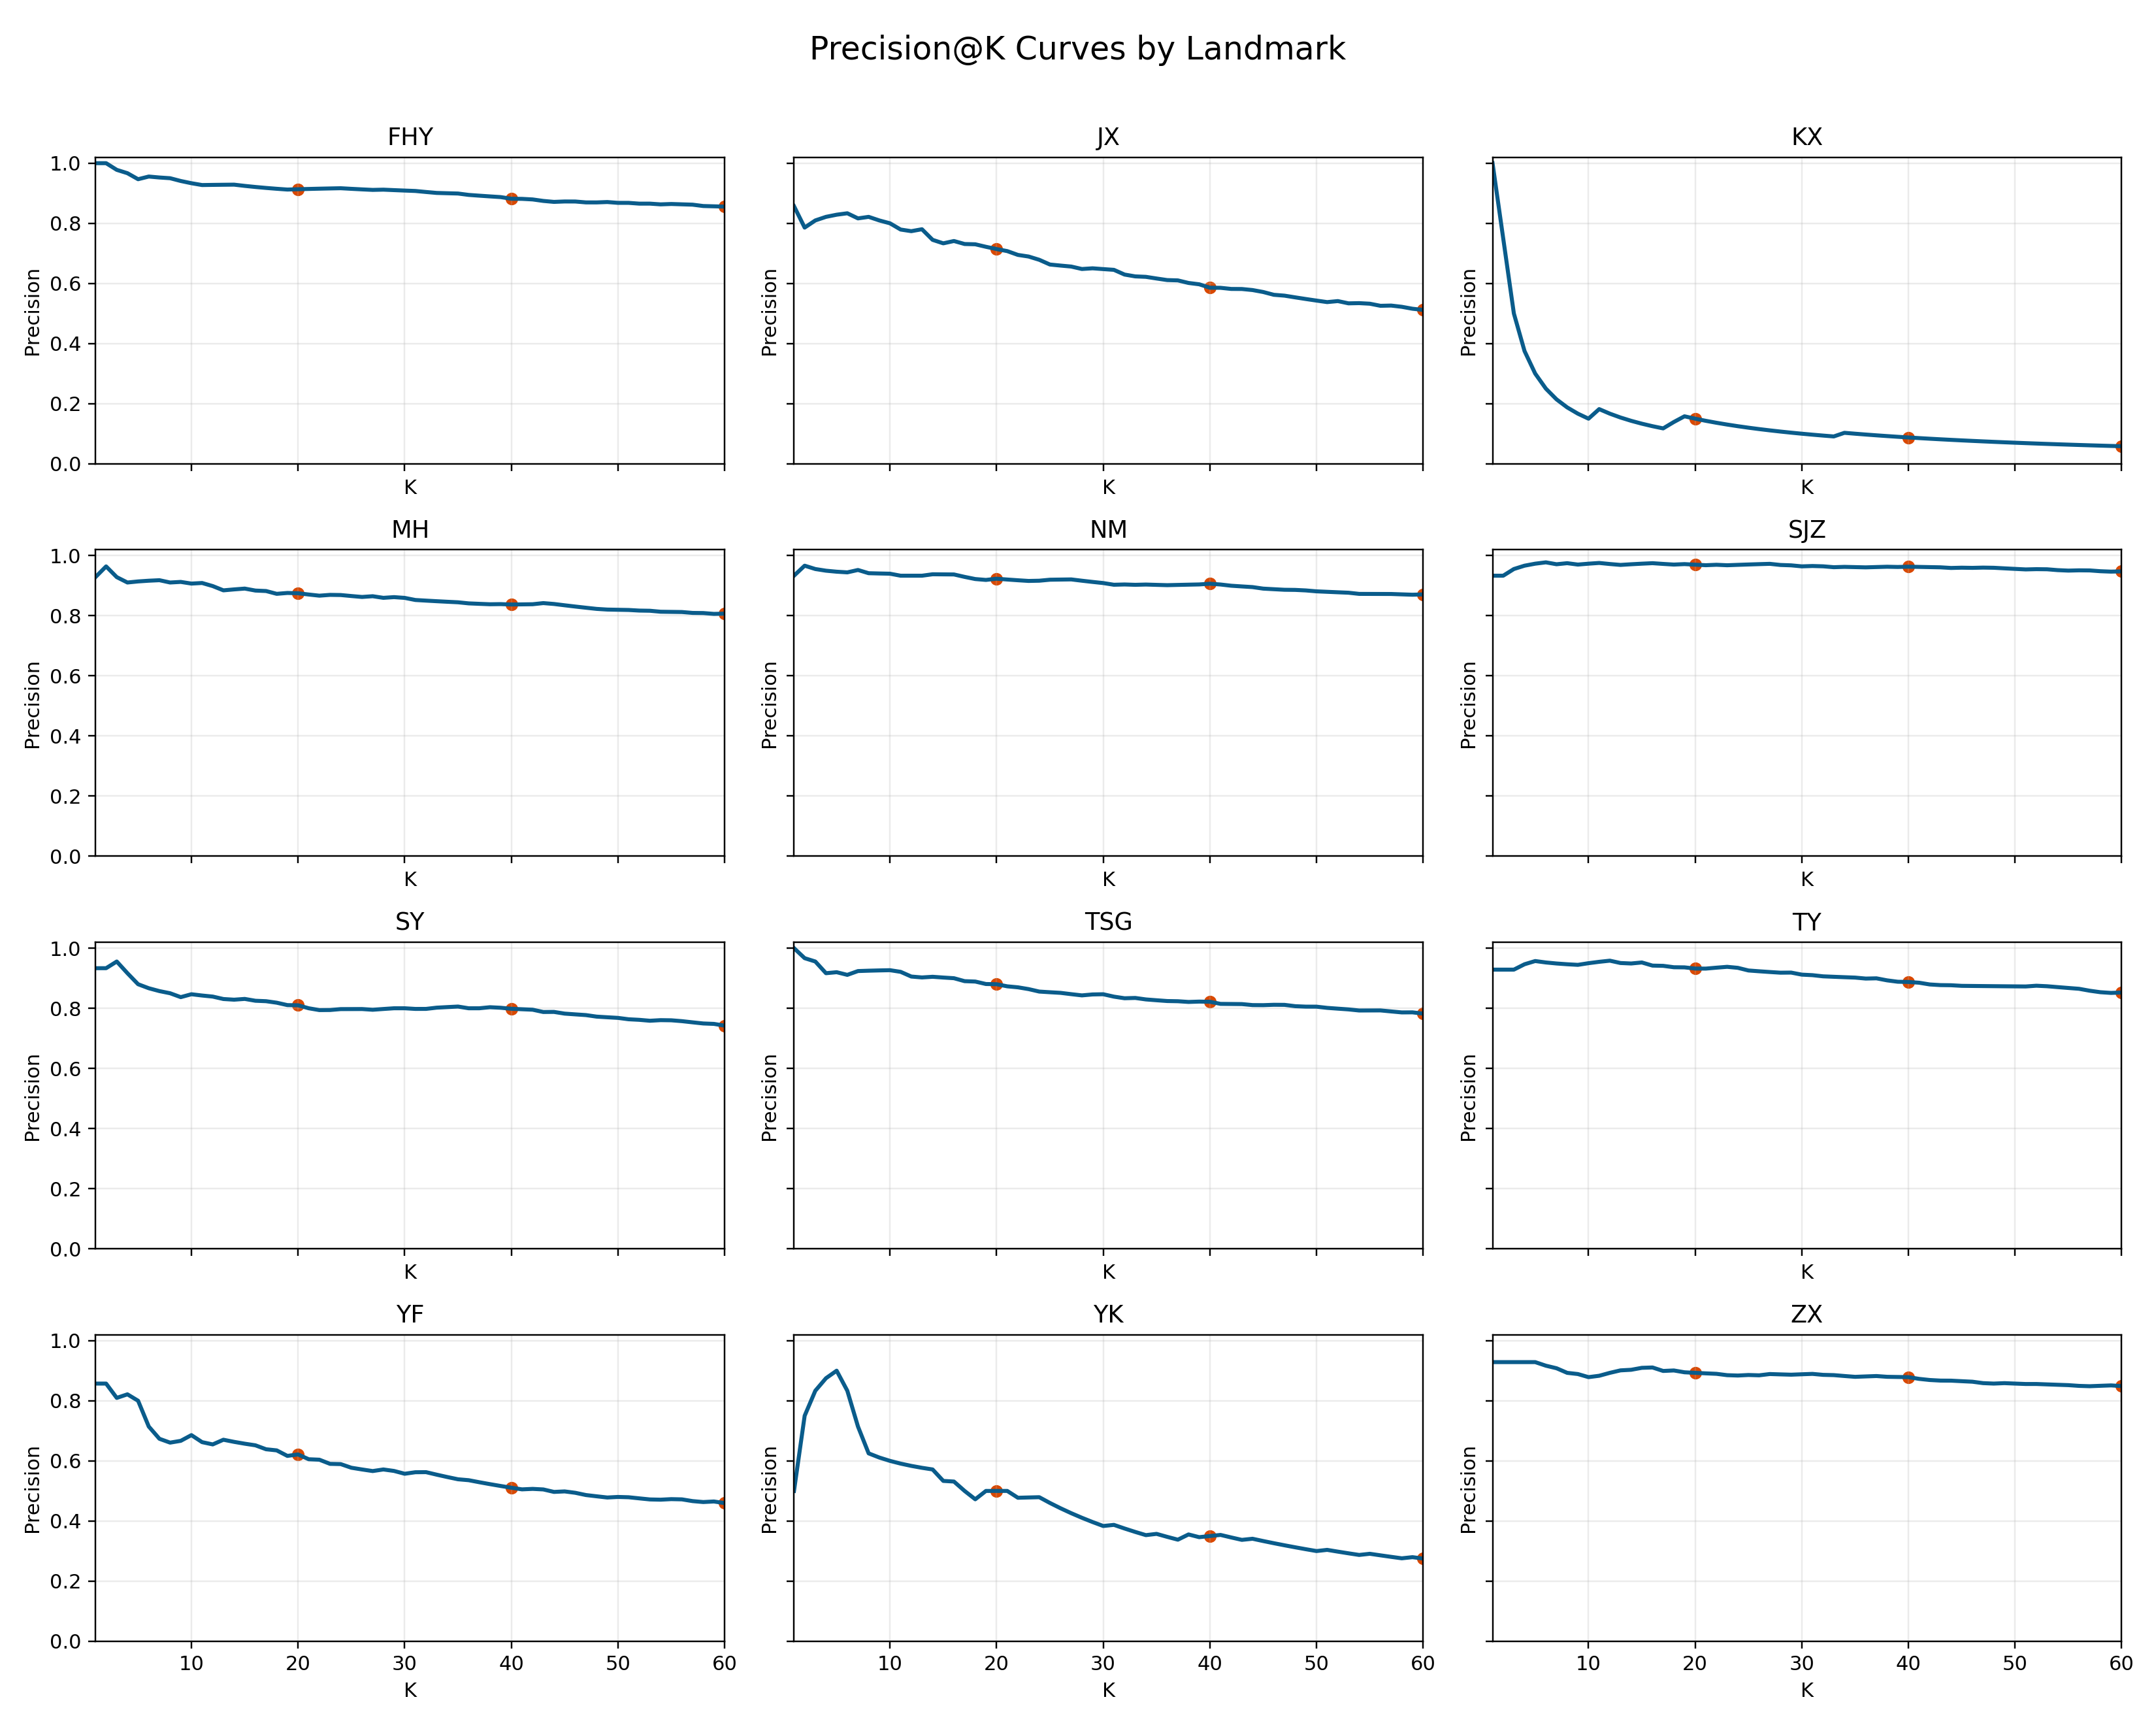

In [6]:
display(IPImage(filename=str(RETRIEVAL_OUT / 'precision_curves.png')))

## 3. 文字检测：从训练到测试

这一步会重新划分检测训练集 / 验证集 / 最终展示样例，并训练检测器。

In [7]:
query_dir = DATASET_ROOT / 'image_retrieval' / 'query'
retrieval_base_dir = DATASET_ROOT / 'image_retrieval' / 'base' / 'BJTU'
all_records = load_detection_records(detection_root)
holdout_names = set(grouped_holdout_query_names(query_dir, count_per_prefix=2))
train_records, val_records, holdout_records = split_records_by_prefix(
    records=all_records,
    holdout_names=holdout_names,
    val_ratio=VAL_RATIO,
    seed=SEED,
)

show_markdown_table(
    ['划分', '数量'],
    [
        ['train_records', len(train_records)],
        ['val_records', len(val_records)],
        ['holdout_records', len(holdout_records)],
    ],
    title='检测数据划分'
)

train_loader = DataLoader(
    DetectionDataset(train_records),
    batch_size=DETECTION_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_detection,
)

detection_model = build_model(num_classes=2).to(device)
optimizer = torch.optim.SGD(
    [parameter for parameter in detection_model.parameters() if parameter.requires_grad],
    lr=DETECTION_LR,
    momentum=0.9,
    weight_decay=0.0005,
)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=max(DETECTION_EPOCHS // 2, 1),
    gamma=0.2,
)

history = []
best_state = None
best_val_f1 = -1.0

### 检测数据划分

| 划分 | 数量 |
| --- | --- |
| train_records | 1324 |
| val_records | 146 |
| holdout_records | 24 |

In [8]:
for epoch in range(1, DETECTION_EPOCHS + 1):
    train_loss = train_one_epoch(detection_model, train_loader, optimizer, device)
    scheduler.step()

    val_metrics, _ = evaluate_predictions(
        model=detection_model,
        records=val_records,
        device=device,
        score_threshold=SCORE_THRESHOLD,
        iou_threshold=IOU_THRESHOLD,
    )
    holdout_metrics, _ = evaluate_predictions(
        model=detection_model,
        records=holdout_records,
        device=device,
        score_threshold=SCORE_THRESHOLD,
        iou_threshold=IOU_THRESHOLD,
    )

    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'val_precision': val_metrics.precision,
        'val_recall': val_metrics.recall,
        'val_f1': val_metrics.f1,
        'val_mean_iou': val_metrics.mean_iou,
        'holdout_precision': holdout_metrics.precision,
        'holdout_recall': holdout_metrics.recall,
        'holdout_f1': holdout_metrics.f1,
        'holdout_mean_iou': holdout_metrics.mean_iou,
    })

    if val_metrics.f1 > best_val_f1:
        best_val_f1 = val_metrics.f1
        best_state = {name: value.detach().cpu() for name, value in detection_model.state_dict().items()}

    print({
        'epoch': epoch,
        'train_loss': round(train_loss, 4),
        'val_f1': round(val_metrics.f1, 4),
        'holdout_f1': round(holdout_metrics.f1, 4),
    })

if best_state is None:
    raise RuntimeError('No valid detection checkpoint was produced.')

detection_model.load_state_dict(best_state)

{'epoch': 1, 'train_loss': 0.4423, 'val_f1': 0.5892, 'holdout_f1': 0.4}
{'epoch': 2, 'train_loss': 0.4529, 'val_f1': 0.6693, 'holdout_f1': 0.4571}
{'epoch': 3, 'train_loss': 0.4602, 'val_f1': 0.7012, 'holdout_f1': 0.5143}
{'epoch': 4, 'train_loss': 0.4377, 'val_f1': 0.696, 'holdout_f1': 0.5143}


<All keys matched successfully>

In [9]:
final_val_metrics, _ = evaluate_predictions(
    model=detection_model,
    records=val_records,
    device=device,
    score_threshold=SCORE_THRESHOLD,
    iou_threshold=IOU_THRESHOLD,
)
final_holdout_metrics, holdout_predictions = evaluate_predictions(
    model=detection_model,
    records=holdout_records,
    device=device,
    score_threshold=SCORE_THRESHOLD,
    iou_threshold=IOU_THRESHOLD,
)

torch.save(best_state, DETECTION_OUT / 'best_detector.pt')
plot_training_curve(history, DETECTION_OUT / 'training_curve.png')

detection_metrics = {
    'config': {
        'epochs': DETECTION_EPOCHS,
        'batch_size': DETECTION_BATCH_SIZE,
        'learning_rate': DETECTION_LR,
        'val_ratio': VAL_RATIO,
        'score_threshold': SCORE_THRESHOLD,
        'iou_threshold': IOU_THRESHOLD,
    },
    'splits': {
        'train_records': len(train_records),
        'val_records': len(val_records),
        'holdout_records': len(holdout_records),
    },
    'history': history,
    'best_val_f1': best_val_f1,
    'final_val_metrics': vars(final_val_metrics),
    'final_holdout_metrics': vars(final_holdout_metrics),
}

(DETECTION_OUT / 'detection_metrics.json').write_text(
    json.dumps(detection_metrics, indent=2, ensure_ascii=False),
    encoding='utf-8',
)
(DETECTION_OUT / 'holdout_predictions.json').write_text(
    json.dumps(holdout_predictions, indent=2, ensure_ascii=False),
    encoding='utf-8',
)

show_markdown_table(
    ['验证集指标', '数值'],
    [[key, f'{value:.3f}' if isinstance(value, float) else value] for key, value in vars(final_val_metrics).items()],
    title='最终验证集结果'
)
show_markdown_table(
    ['24 张展示样例指标', '数值'],
    [[key, f'{value:.3f}' if isinstance(value, float) else value] for key, value in vars(final_holdout_metrics).items()],
    title='最终 Holdout 结果'
)

### 最终验证集结果

| 验证集指标 | 数值 |
| --- | --- |
| precision | 0.854 |
| recall | 0.595 |
| f1 | 0.701 |
| mean_iou | 0.745 |
| matched | 88 |
| predicted | 103 |
| targets | 148 |

### 最终 Holdout 结果

| 24 张展示样例指标 | 数值 |
| --- | --- |
| precision | 0.818 |
| recall | 0.375 |
| f1 | 0.514 |
| mean_iou | 0.783 |
| matched | 9 |
| predicted | 11 |
| targets | 24 |

In [10]:
panel_paths = []
for record in holdout_records:
    query_image = safe_open_image(record.image_path)
    if query_image is None:
        continue
    prediction = holdout_predictions.get(record.image_path.name, {})
    pred_boxes = prediction.get('pred_boxes', [])
    detected_image = draw_boxes(query_image, pred_boxes, color='#d94801', width=5)

    retrieved_images = []
    for rank, retrieved_name in enumerate(top60_rankings.get(record.image_path.name, [])[:5], start=1):
        image = safe_open_image(retrieval_base_dir / retrieved_name)
        if image is None:
            continue
        is_correct = image_prefix(retrieved_name) == record.prefix
        retrieved_images.append((image, is_correct, f'#{rank} {retrieved_name}'))

    title = f'{record.prefix.upper()} | {record.image_path.name}'
    panel = compose_visual_panel(query_image, detected_image, retrieved_images, title)
    panel_path = VISUAL_OUT / f'{record.prefix}_{record.image_path.stem}.jpg'
    panel.save(panel_path, quality=92)
    panel_paths.append(panel_path)

build_contact_sheet(sorted(panel_paths), DETECTION_OUT / 'visualizations_contact_sheet.jpg')
print('Generated panels:', len(panel_paths))

Generated panels: 24


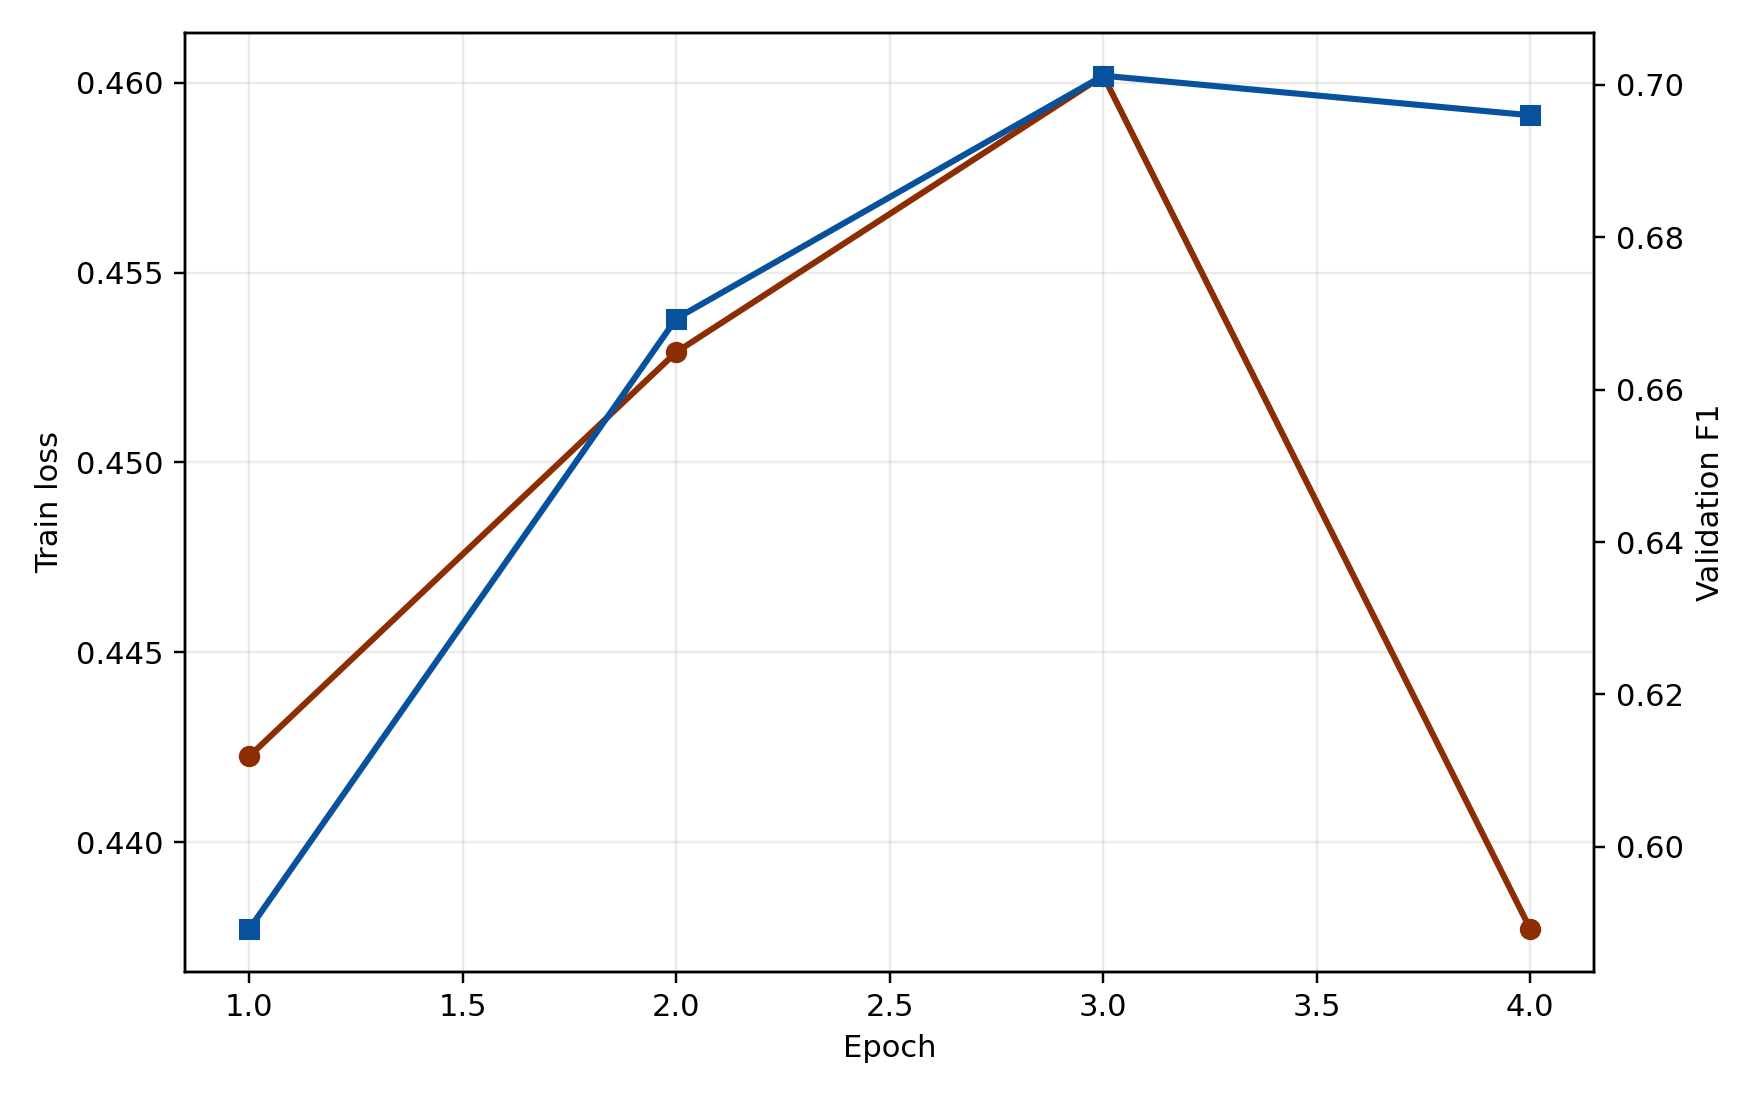

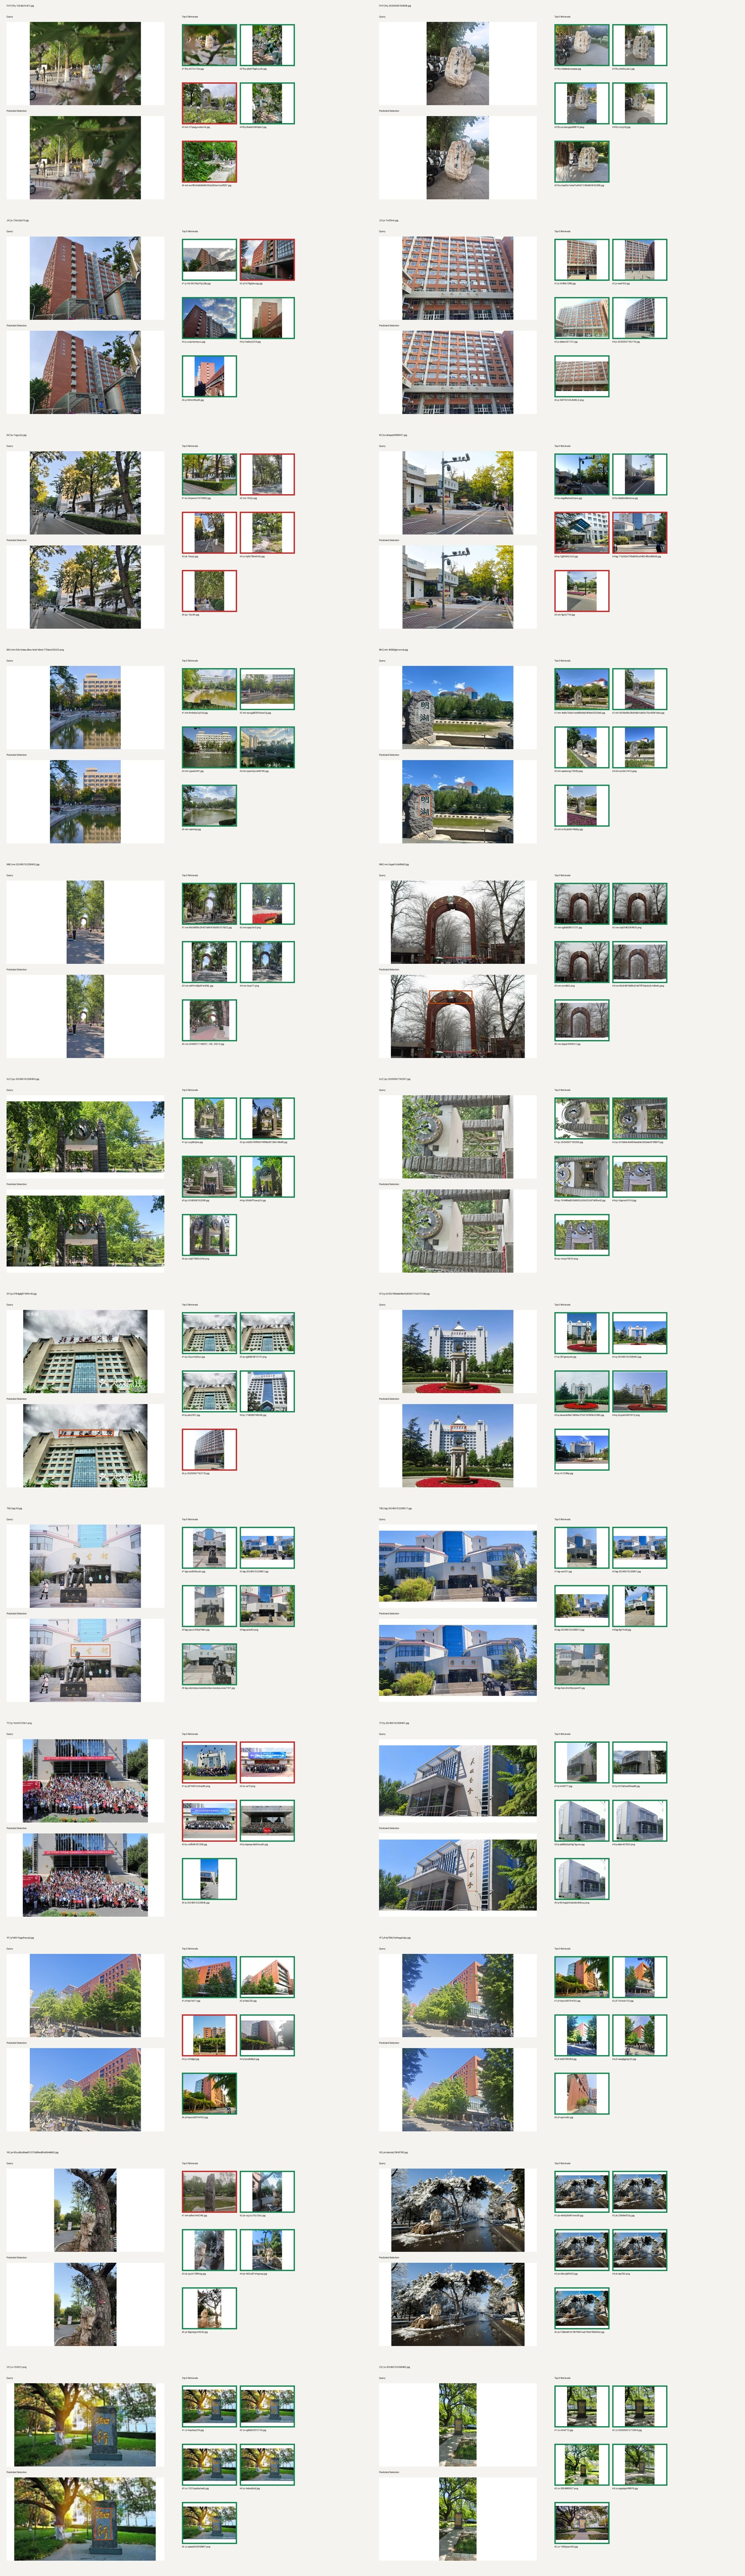

In [11]:
display(IPImage(filename=str(DETECTION_OUT / 'training_curve.png')))
display(IPImage(filename=str(DETECTION_OUT / 'visualizations_contact_sheet.jpg')))

## 4. 运行完成后的结果位置

这个完整运行版 Notebook 会把结果写到：

- `outputs/notebook_full_pipeline/retrieval/`
- `outputs/notebook_full_pipeline/detection/`
